# 03 — Training runner, pre-configured: `c3_ft` (13th test row)

A copy of the `03_train` template with `RUN` pre-set — open, run all.

**What this run is** (approved 2026-07-19; recipe pre-registered in
`configs/c3_ft.yaml` + `splits/CHANGELOG.md`): CE fine-tuning of C3's
SupCon encoder from `C3/epoch40.ckpt` — full network, fresh head, peak
LR 1e-4, otherwise byte-identical to the C1 recipe. It answers the
fairness question ("was the linear probe holding SupCon back?") with a
protected floor. Pre-registered hypothesis: comparable to C1 (±1 pt);
success = comparable, not beats.

**Requires**: read access to the Drive folder holding `C3/epoch40.ckpt`
(shortcut, as for phase B) and write access to your `ckpt_root` (the
run creates `C3_ft/`). Watch the FIRST log line after launch: it must
say `backbone initialized from .../C3/epoch40.ckpt ... head starts
fresh` — if it says nothing about init, the config didn't reach the
wiring: STOP and check the clone is on current main.

Archive the executed copy under `notebooks/runs/` as
`YYYY-MM-DD_c3_ft.ipynb`, as for every run.


## Environment setup

This notebook is not one run per file. Instead:

- one notebook = one runner
- one config = one experiment
- different people can use the same notebook with different config values

In Colab, the notebook runs on a remote VM. If the repo is not already
available there, this notebook will clone it from GitHub. It also stages
data from the shared Drive archive into `/content/data` using the
paths defined in `configs/paths.yaml`.


In [1]:
from pathlib import Path
import subprocess
import sys
import torch
import zipfile

REPO_URL = "https://github.com/FilippoIsoni/sharp-har.git"

# Locate or clone the repository root containing the sharp_har package.
# In Colab, the notebook may run from a temporary working directory.
cwd = Path.cwd().resolve()
if (cwd / "sharp_har").exists():
    REPO_DIR = cwd
elif (cwd.parent / "sharp_har").exists():
    REPO_DIR = cwd.parent
elif (cwd.parent.parent / "sharp_har").exists():
    REPO_DIR = cwd.parent.parent
else:
    REPO_DIR = Path("/content/sharp-har")
    if not REPO_DIR.exists():
        REPO_DIR.parent.mkdir(parents=True, exist_ok=True)
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

# After the clone, so the file actually exists on a fresh runtime.
!pip install -q -r {REPO_DIR}/requirements.txt

sys.path.insert(0, str(REPO_DIR))

from google.colab import drive
from sharp_har.train import train_run
from sharp_har.utils import read_yaml

paths_cfg = read_yaml(REPO_DIR / "configs" / "paths.yaml")
drive_root = Path(paths_cfg["drive_root"])
stage_dir = Path(paths_cfg["stage_dir"])
CKPT_ROOT = Path(paths_cfg["ckpt_root"])

# Mount Drive unconditionally (idempotent): checkpoints are written to
# CKPT_ROOT on Drive even when the data is already staged on the VM.
drive.mount("/content/drive")

# Stage the zip archives if needed (same convention as 00_setup_smoke).
if not (stage_dir.exists() and any(stage_dir.rglob("*.txt"))):
    stage_dir.mkdir(parents=True, exist_ok=True)
    for zip_name in paths_cfg["zips"]:
        src = drive_root / zip_name
        dst = Path("/content") / zip_name
        print(f"copying {src} -> {dst}")
        subprocess.run(["cp", str(src), str(dst)], check=True)
        with zipfile.ZipFile(dst) as zf:
            zf.extractall(stage_dir)

print("Repo dir:", REPO_DIR)
print("sharp_har exists:", (REPO_DIR / "sharp_har").exists())
print("GPU available:", torch.cuda.is_available())
print("Stage dir:", stage_dir)
print("Checkpoint root:", CKPT_ROOT)


Mounted at /content/drive
copying /content/drive/MyDrive/DATASET_SHARP/doppler_traces.zip -> /content/doppler_traces.zip
copying /content/drive/MyDrive/DATASET_SHARP/doppler_traces_S4_S5.zip -> /content/doppler_traces_S4_S5.zip
Repo dir: /content/sharp-har
sharp_har exists: True
GPU available: True
Stage dir: /content/data
Checkpoint root: /content/drive/MyDrive/sharp_har_runs


In [2]:
# GPU sanity check - run BEFORE launching training (see the C3 OOM incident).
# Expected on a clean runtime: no processes listed, ~0 MiB used. If not:
# Runtime -> Disconnect and delete runtime, then rerun from the top.
!nvidia-smi

import torch
free, total = torch.cuda.mem_get_info()
print(f"free: {free/2**30:.2f} GiB / total: {total/2**30:.2f} GiB")
assert free / 2**30 > 10, (
    "GPU is not clean: less than 10 GiB free before training. "
    "Something else is holding memory - delete the runtime and start over."
)
print("GPU clean - OK to launch.")

Sun Jul 19 07:54:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Load config and launch the run

Choose one config stem below and run the cell. The config name
determines which experiment is executed.


In [3]:
RUN = "c3_ft"  # pre-registered 13th row - do not change in-session
cfg = read_yaml(REPO_DIR / "configs" / f"{RUN}.yaml")

print("Selected run:", RUN)
print("Config summary:")
print(cfg)

out = train_run(cfg, stage_dir=stage_dir, ckpt_dir=CKPT_ROOT, repo_dir=REPO_DIR)
print("Train run finished:", out)


2026-07-19 07:54:14,112 [INFO] sharp_har.data: train: 81 traces, 53400 (window, antenna) samples (win=340, stride=100)
2026-07-19 07:54:14,130 [INFO] sharp_har.data: val: 9 traces, 1396 (window, antenna) samples (win=340, stride=340)


Selected run: c3_ft
Config summary:
{'name': 'C3_ft', 'seed': 42, 'protocol': 'P2-lab', 'split_file': 'splits/p2_lab.json', 'backbone': 'resnet_vb', 'd_enc': 256, 'n_att': 8, 'init_ckpt': 'C3/epoch40.ckpt', 'loss': {'type': 'ce', 'label_smoothing': 0.1}, 'adversary': {'type': None, 'target': 'ar_set', 'lambda_max': None, 'beta': None}, 'optim': {'name': 'adamw', 'lr': 0.0001, 'wd': 0.0001, 'warmup_epochs': 5, 'scheduler': 'cosine'}, 'train': {'epoch_steps': 400, 'max_epochs': 40, 'batch_size': 256, 'sampler': 'uniform', 'amp': True, 'grad_clip': 1.0}, 'eval': {'select_metric': 'val_macro_f1', 'patience': 10}}


2026-07-19 07:54:23,218 [INFO] sharp_har.train: C3_ft: backbone initialized from /content/drive/MyDrive/sharp_har_runs/C3/epoch40.ckpt (C3, epoch 40); head starts fresh
2026-07-19 07:58:14,282 [INFO] sharp_har.train: C3_ft epoch 1/40: loss 1.9335, val macro-F1 0.5691, 0.571 s/step
2026-07-19 08:01:59,766 [INFO] sharp_har.train: C3_ft epoch 2/40: loss 1.3079, val macro-F1 0.7016, 0.557 s/step
2026-07-19 08:05:37,811 [INFO] sharp_har.train: C3_ft epoch 3/40: loss 1.0305, val macro-F1 0.8104, 0.539 s/step
2026-07-19 08:09:16,989 [INFO] sharp_har.train: C3_ft epoch 4/40: loss 0.8954, val macro-F1 0.8183, 0.541 s/step
2026-07-19 08:12:56,250 [INFO] sharp_har.train: C3_ft epoch 5/40: loss 0.8115, val macro-F1 0.6849, 0.541 s/step
2026-07-19 08:16:43,225 [INFO] sharp_har.train: C3_ft epoch 6/40: loss 0.7555, val macro-F1 0.7724, 0.562 s/step
2026-07-19 08:20:30,298 [INFO] sharp_har.train: C3_ft epoch 7/40: loss 0.7227, val macro-F1 0.7271, 0.562 s/step
2026-07-19 08:24:17,441 [INFO] sharp_har

Train run finished: {'run_dir': PosixPath('/content/drive/MyDrive/sharp_har_runs/C3_ft'), 'best_val_macro_f1': 0.8182873115910198, 'history': [{'epoch': 1, 'train_loss': 1.9335278421640396, 'val_macro_f1': 0.5690588193421925, 'lr': 2.0050000000000003e-05, 's_per_step': 0.5710344767570495, 'epoch_seconds': 228.41379070281982}, {'epoch': 2, 'train_loss': 1.307916219830513, 'val_macro_f1': 0.7015653056802655, 'lr': 4.0050000000000004e-05, 's_per_step': 0.5565228545665741, 'epoch_seconds': 222.60914182662964}, {'epoch': 3, 'train_loss': 1.0305211982131004, 'val_macro_f1': 0.8103652783023539, 'lr': 6.005000000000001e-05, 's_per_step': 0.5392521280050278, 'epoch_seconds': 215.7008512020111}, {'epoch': 4, 'train_loss': 0.8953655014932156, 'val_macro_f1': 0.8182873115910198, 'lr': 8.005000000000001e-05, 's_per_step': 0.5412749403715134, 'epoch_seconds': 216.50997614860535}, {'epoch': 5, 'train_loss': 0.8115086390078068, 'val_macro_f1': 0.6848894568717883, 'lr': 0.0001, 's_per_step': 0.54119209

## Training curves

Per-epoch diagnostics read from the run's `history.csv` (§0.4). The
panels adapt to the run: train loss and throughput always; fused val
macro-F1 with the val-selected best epoch on CE runs (C0/C1/C2); the
mandatory §6-C2 GRL monitoring pair (AR-set train accuracy vs λ ramp)
on C2/C4; learning rate. Re-run this cell any time — it re-reads the
CSV, so it also works on a resumed or still-running run.

Related helpers in `sharp_har.viz`: `plot_confusion(csv)` for the
harness `*_confusion.csv` files, `compare_runs({name: run_dir, ...})`
to overlay a metric across configs (remember §0.5: differences under
~2 points are "comparable", not improvements).


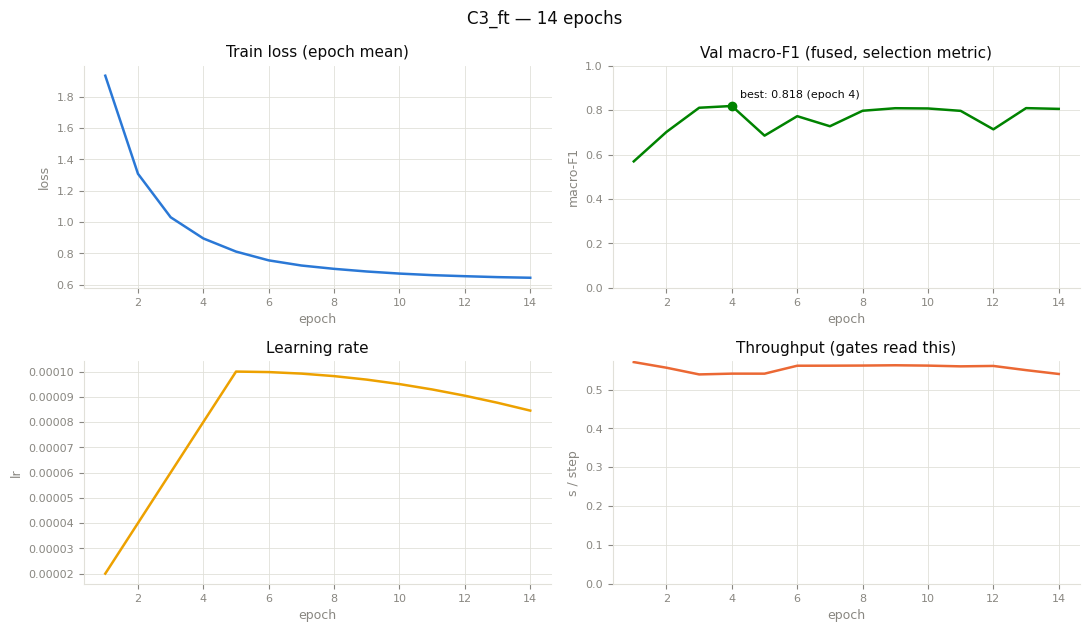

In [4]:
# Thin runner: all plotting logic lives in sharp_har.viz.
from sharp_har.viz import plot_history

run_dir = CKPT_ROOT / cfg["name"]
plot_history(run_dir);


## Archiving the definitive run notebook

This notebook stays a **clean template** (outputs cleared on Git). The
executed copy of a real run is a measured artifact and is committed
verbatim, like the gate reports:

1. When the run (or a resumed segment) ends, download the executed
   notebook (`File → Download → .ipynb`) **with its outputs**.
2. Commit it under `notebooks/runs/` as `YYYY-MM-DD_<config>.ipynb`
   (e.g. `2026-07-16_c0_sharp.ipynb`); add a `_partN` suffix if one run
   spans several resumed sessions. Never edit archived outputs.
3. The run's numeric artifacts still live in `ckpt_root/<name>/`
   (`history.csv`, `run_meta.json`, checkpoints) — the archived
   notebook is the human-readable record, not a data source.

See `notebooks/runs/README.md` for the full convention.
